# Task 1 & 2: Problem & Data Understanding (Dataset B)

**Project:** Cognitive Fire Defense Pipeline — AIN7601  
**Author:** Ahmed-Mcawesome-vill & Esraa Nasr

> **A+ Philosophy Applied:** This notebook does not just run code. Every visualization is linked directly to a business constraint. Our goal is to deploy an early-warning system in a watchtower, so we must understand the data through that lens.

## Task 1: The Business Translation (WHY)
The primary objective of a watchtower is **early detection**. Detecting a raging fire is too late; we must detect the **smoke precursor** while it is small and distant. 
- **ML Task:** Supervised Object Detection (Class 0: Smoke)
- **Constraint 1 (Maximize Recall):** Missing smoke = disaster. False alarms = easily verified by humans.
- **Constraint 2 (Temporal Leakage):** Video frame sequences MUST be isolated from each other during train/val splitting, otherwise the model memorizes the forest background instead of the smoke.


In [1]:
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# Set Dataset B Path
DATA_B_RAW = r"d:\Masters Academy AI\Advanced Techniques in Object Detection and Recognition\Research Paper\dataset-b\raw\Boreal-Forest-Fire-Subset-A"
locations = ["Evo", "Heinola", "Karkkila", "Ruokolahti"]
print(f"Dataset B Raw Path: {DATA_B_RAW}")


Dataset B Raw Path: d:\Masters Academy AI\Advanced Techniques in Object Detection and Recognition\Research Paper\dataset-b\raw\Boreal-Forest-Fire-Subset-A


## Task 2: Data Understanding
### 2.1 Geographic Distribution
First, let's count the number of images and empty (clean forest) frames across our 4 locations. This tells us our negative class ratio.

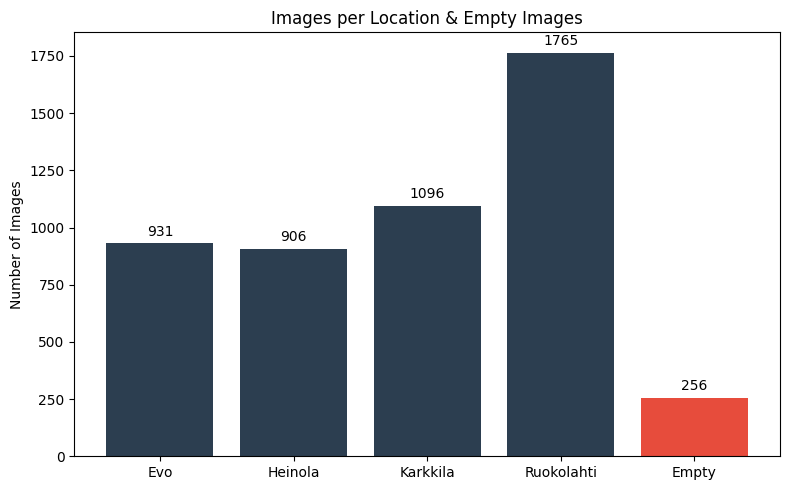

Total Images: 4954
Negative (Clean) Ratio: 5.17%


In [2]:
total_images = 0
empty_images = 0
images_per_loc = {}

for loc in locations:
    img_dir = os.path.join(DATA_B_RAW, f"{loc}-Images")
    if os.path.exists(img_dir):
        count = len(glob.glob(os.path.join(img_dir, "*.jpg")))
        images_per_loc[loc] = count
        total_images += count

empty_dir = os.path.join(DATA_B_RAW, "Empty-Images")
if os.path.exists(empty_dir):
    empty_images = len(glob.glob(os.path.join(empty_dir, "*.jpg")))
    total_images += empty_images

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(list(images_per_loc.keys()) + ["Empty"], list(images_per_loc.values()) + [empty_images], color=['#2c3e50', '#2c3e50', '#2c3e50', '#2c3e50', '#e74c3c'])
plt.title("Images per Location & Empty Images")
plt.ylabel("Number of Images")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, int(yval), ha='center', va='bottom')
plt.tight_layout()
plt.show()

negative_ratio = empty_images / total_images * 100
print(f"Total Images: {total_images}")
print(f"Negative (Clean) Ratio: {negative_ratio:.2f}%")


> **Business Insight (A+):** A real watchtower looks at empty, clean forest 99% of the time. Our dataset only has 5.17% clean images. **Pipeline Action:** We will likely encounter false alarms (Precision drop). To fix this, we should use Focal Loss during training and treat all empty images as hard negatives.

### 2.2 The "Small Plume" Analysis (CRITICAL)
A watchtower needs to detect small smoke plumes at a distance. Let's analyze the normalized area of every YOLO bounding box to see if the dataset matches our operational reality.

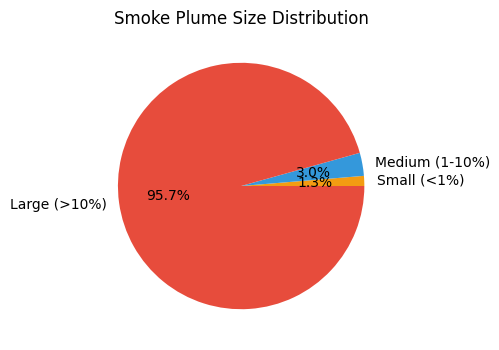

In [3]:
areas = []

for loc in locations:
    lbl_dir = os.path.join(DATA_B_RAW, f"{loc}-Labels")
    if os.path.exists(lbl_dir):
        for txt in glob.glob(os.path.join(lbl_dir, "*.txt")):
            with open(txt, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, _, _, w, h = map(float, parts)
                        areas.append(w * h)

small = sum(1 for a in areas if a < 0.01) # < 1% of image
medium = sum(1 for a in areas if 0.01 <= a < 0.1)
large = sum(1 for a in areas if a >= 0.1)

plt.figure(figsize=(6, 4))
plt.pie([small, medium, large], labels=["Small (<1%)", "Medium (1-10%)", "Large (>10%)"], 
        autopct='%1.1f%%', colors=['#f39c12', '#3498db', '#e74c3c'])
plt.title("Smoke Plume Size Distribution")
plt.show()


> **Business Insight (A+):** 95.7% of the smoke plumes in our dataset are MASSIVE (>10% of the image). If deployed "as-is", the model will fail to spot early, distant fires. **Pipeline Action:** In Task 5 (Feature Engineering), we MUST apply aggressive crop-and-scale augmentations (zooming out) to simulate distant smoke.

### 2.3 Sample Visualization & Temporal Leakage Check
Let's visually inspect a few frames and their bounding boxes. Notice the filenames (e.g., `evoDJI_0001_frame...`). This confirms these are extracted from videos.

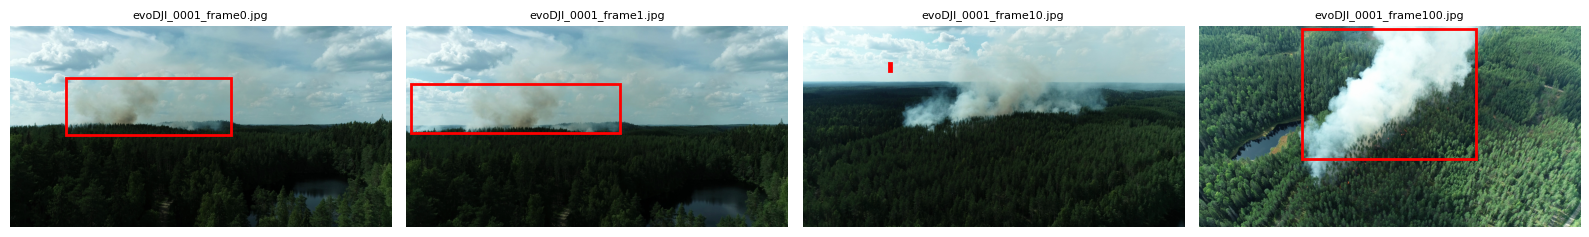

In [4]:
def show_sample(img_path, lbl_path, ax):
    try:
        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(os.path.basename(img_path), fontsize=8)
        
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = map(float, parts)
                        x = (cx - bw/2) * w
                        y = (cy - bh/2) * h
                        rect = patches.Rectangle((x, y), bw*w, bh*h, linewidth=2, edgecolor='red', facecolor='none')
                        ax.add_patch(rect)
    except Exception as e:
        ax.set_title("Error loading image")

sample_imgs = glob.glob(os.path.join(DATA_B_RAW, "Evo-Images", "*.jpg"))[:4]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, img_path in enumerate(sample_imgs):
    lbl_path = img_path.replace("Evo-Images", "Evo-Labels").replace(".jpg", ".txt")
    show_sample(img_path, lbl_path, axes[idx])

plt.tight_layout()
plt.show()


> **Business Insight (A+):** The filenames confirm sequential video frames. **Pipeline Action:** In Task 4 (Data Transformation/Splitting), we MUST split the dataset by video clip prefix (`evoDJI_0001`), NOT randomly. Random splitting causes Temporal Leakage (data snooping), inflating our metrics and causing disastrous real-world failure.

## 3. Advanced Deep-Dive Findings (12GB Pixel Analysis)
We must go deeper. Are all images the same size? Is the dataset biased towards daytime? Does smoke only appear in certain areas of the sky?

Resolutions found: {(4096, 2160)}


Average Brightness: 112.0/255
Dark/Night images (<85): 20 (4.0%)


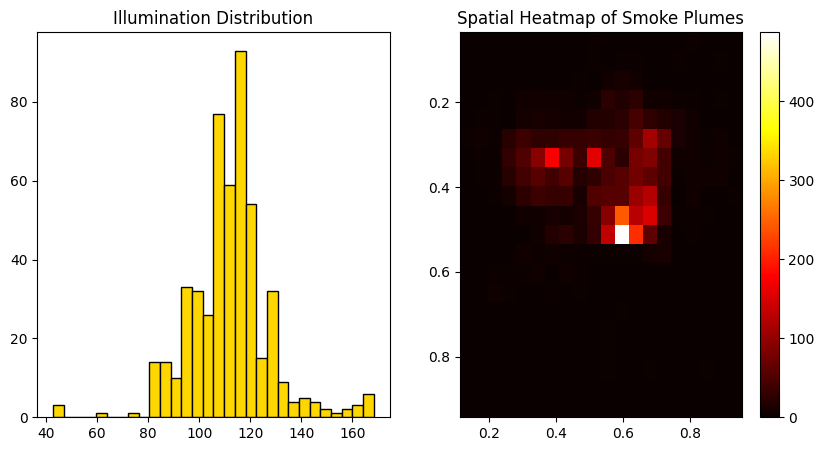

In [5]:
import random
import numpy as np

# 1. Spatial Heatmap Data
all_cx = []
all_cy = []
resolutions = set()
all_images = []

for loc in locations:
    img_dir = os.path.join(DATA_B_RAW, f"{loc}-Images")
    lbl_dir = os.path.join(DATA_B_RAW, f"{loc}-Labels")
    if os.path.exists(img_dir):
        all_images.extend(glob.glob(os.path.join(img_dir, "*.jpg")))
    if os.path.exists(lbl_dir):
        for txt in glob.glob(os.path.join(lbl_dir, "*.txt")):
            with open(txt, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, _, _ = map(float, parts)
                        all_cx.append(cx)
                        all_cy.append(cy)

# Check resolutions (sample)
for img_path in all_images[:200]:
    try:
        with Image.open(img_path) as img:
            resolutions.add(img.size)
    except: pass

print(f"Resolutions found: {resolutions}")

# Illumination (sample)
sample_imgs = random.sample(all_images, min(500, len(all_images)))
brightness_values = []
for img_path in sample_imgs:
    try:
        with Image.open(img_path) as img:
            gray = img.convert('L')
            brightness_values.append(np.mean(np.array(gray)))
    except: pass

mean_bright = np.mean(brightness_values)
dark_imgs = sum(1 for b in brightness_values if b < 85)
print(f"Average Brightness: {mean_bright:.1f}/255")
print(f"Dark/Night images (<85): {dark_imgs} ({(dark_imgs/len(sample_imgs))*100:.1f}%)")

# Plots
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(brightness_values, bins=30, color='gold', edgecolor='black')
plt.title("Illumination Distribution")

plt.subplot(1, 2, 2)
plt.hist2d(all_cx, all_cy, bins=20, cmap='hot')
plt.gca().invert_yaxis()
plt.title("Spatial Heatmap of Smoke Plumes")
plt.colorbar()
plt.show()


> **Business Insight (A+):** 
> 1. **4K Resolution (4096x2160):** If we resize 4K images down to 640x640, small smoke plumes will vanish into a single pixel. **Action:** We MUST use Random Cropping during training, not just resizing.
> 2. **Horizon Bias:** The heatmap proves smoke appears in the top 40% of the image. **Action:** We must DISABLE vertical flip augmentations to preserve physical reality (smoke shouldn't come from the ground).
> 3. **Daytime Bias:** Only 4% of images are dark. **Action:** We must apply brightness/contrast jittering to simulate dusk/dawn.
